<a href="https://colab.research.google.com/github/jennygn/Ejercicios/blob/main/02_Agrupamiento_Jerarquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/Curso-FundMachineLearning/blob/main/4-Ejercicios/02-Agrupamiento-Jerarquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i0.wp.com/see-ec.org/wordpress/wp-content/uploads/2023/01/LOGO-SEE-texto-blanco-3.png?w=1356&ssl=1" width="200">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#008dc3" size="7">|</font><br>
            <font color="#008dc3" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="5">
                <b>Sociedad Ecuatoriana de Estadística</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="4">
                Aprendizaje Automático Inicial &bull; Agrupamiento Jerarquico
            </font></p>
            <p style="font-style: oblique;"><font color="#008dc3" size="3">
                Andrés Merino &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='008dc3'> Introducción </font>

A lo largo de este taller, aplicaremos el algoritmo de agrupamiento jerárquico a un conjunto de datos.

Los paquetes necesarios son:

In [68]:
# Paquetes necesarios
import pandas as pd # Para manejo de datos
import matplotlib.pyplot as plt # Para visualización
import numpy as np # Para manejo de arreglos
import plotly.express as px # Para visualización
from scipy.spatial.distance import cdist # Para cálculo de distancias
# Modelo de clustering jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
# Estandarización de datos
from sklearn.preprocessing import StandardScaler
# Para PCA
from sklearn.decomposition import PCA
# Métricas de evaluación
from sklearn.metrics import silhouette_score, davies_bouldin_score

---
## <font color='008dc3'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.
Tomo datos de vinos para realizar este ejercicio, con los datos indicados no se ajustaba para la practica.
<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [76]:
# 1. Enlace directo al dataset de vinos (UCI Repository)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data"

# Nombres de las columnas (según la documentación oficial del dataset)
columnas = ['Clase', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity_of_ash', 'Magnesium',
            'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins',
            'Color_intensity', 'Hue', 'OD280', 'Proline']

# 2. Cargar los datos
df = pd.read_csv(url, names=columnas)
# 3. Seleccionar solo las variables numéricas (quitamos la 'Clase' original para que el modelo la descubra solo)
X = df.drop(columns=['Clase'])

In [82]:
# 4. Escalar los datos (Paso obligatorio para clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

---
## <font color='008dc3'> Dendograma </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Genera el dendograma de los datos.
<ul>
  <li>Usa diferentes métricas y funciones de enlace.</li>
  <li>Toma una distancia de corte.</li>
  <li>De manera intutiva, ¿por qué tomaste la métrica y la distancia de corte?</li>
</ul>
</div>

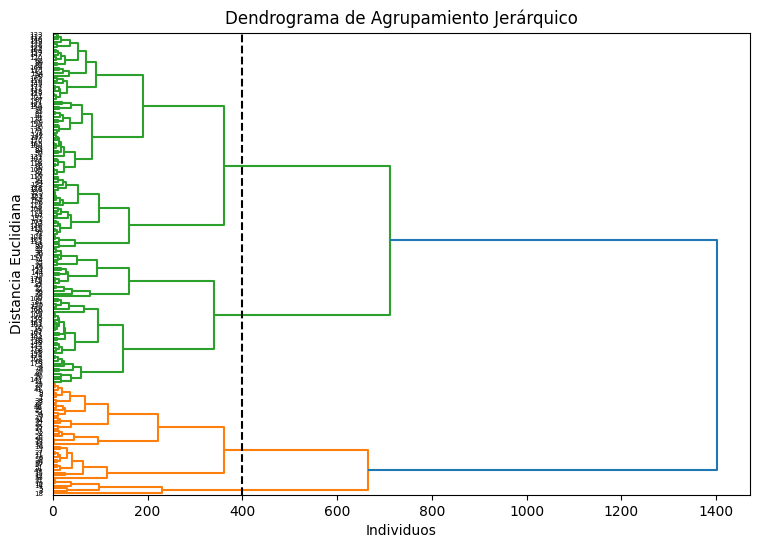

In [79]:
# Realizamos el clustering jerárquico
Z = linkage(X, method='complete')

# Definir la distancia de corte
distancia_corte = 400

# Calcular el dendrograma
plt.figure(figsize=(9, 6))
dendrogram(Z,
    orientation='right', )
plt.axvline(x=distancia_corte, c='k', ls='--')
plt.title("Dendrograma de Agrupamiento Jerárquico")
plt.xlabel("Individuos")
plt.ylabel("Distancia Euclidiana")
plt.show()

---
## <font color='008dc3'> Asignación de grupos y análisis </font>


<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Realiza un análisis de los grupos obtenidos.
<ul>
  <li>Asigna los grupos.</li>
  <li>Revisa la media de cada grupo.</li>
  <li>Revisa el mínimo y máximo de cada grupo.</li>
  <li>Muestra algunos integrantes de cada grupo.</li>
</ul>
</div>

In [86]:

clusters = fcluster(Z, t=distancia_corte, criterion='distance')

# 4. Asegurarnos de que X sea un DataFrame antes de asignar la columna
# Si X ya es un DataFrame, esta línea no le hará daño
X = pd.DataFrame(X)

# 5. Agregar la información de clúster como C1, C2, C3, etc.
X['Cluster'] = ['C' + str(c) for c in clusters]

# Revisar los primeros registros
display(X.head())

,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280,Proline,Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,C2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,C2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,C2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,C1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,C3


In [88]:
# Opcional: Ver cuántos integrantes quedaron en cada grupo
print("\nConteo de integrantes por grupo:")
print(X['Cluster'].value_counts())


Conteo de integrantes por grupo:
Cluster
C4    83
C3    52
C2    37
C1     6
Name: count, dtype: int64


In [89]:
# 1. Análisis de Medias
print("--- MEDIA DE CADA GRUPO ---")
# Calculamos la media solo para las columnas numéricas
resumen_medias = X.groupby('Cluster').mean()
display(resumen_medias)

--- MEDIA DE CADA GRUPO ---


,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
C1,14.136667,1.831667,2.411667,16.266667,107.666667,3.255000,3.493333,0.271667,2.216667,7.233333,1.113333,3.028333,1530.333333
C2,13.762162,1.909459,2.437297,16.837838,104.081081,2.789459,2.938919,0.288649,1.848378,5.539189,1.070541,3.112973,1163.783784
C3,13.057500,2.472692,2.386731,19.501923,105.884615,2.240385,1.778654,0.382115,1.618077,5.652308,0.908385,2.489423,776.634615
C4,12.543373,2.477711,2.319036,20.908434,93.385542,2.039639,1.674940,0.388313,1.413855,4.314096,0.926506,2.434699,485.783133


In [90]:
# 2. Análisis de Mínimos y Máximos (Rangos de los grupos)
print("\n--- VALORES MÍNIMOS Y MÁXIMOS POR GRUPO ---")
# Usamos .agg para obtener ambos valores en una sola tabla
resumen_rangos = X.groupby('Cluster').agg(['min', 'max'])
display(resumen_rangos)


--- VALORES MÍNIMOS Y MÁXIMOS POR GRUPO ---


Alcohol        Malic_acid         Ash       Alcalinity_of_ash        \
            min    max        min   max   min   max               min   max   
Cluster                                                                       
C1        13.58  14.38       1.59  2.16  2.30  2.50              12.0  19.1   
C2        12.85  14.83       1.35  4.04  2.04  2.72              11.2  22.5   
C3        11.61  14.34       0.94  5.65  1.70  3.22              13.2  30.0   
C4        11.03  14.13       0.74  5.80  1.36  3.23              10.6  28.5   

        Magnesium       ... Proanthocyanins       Color_intensity         \
              min  max  ...             min   max             min    max   
Cluster                 ...                                                
C1            102  113  ...            1.86  2.96            5.75   8.70   
C2             89  132  ...            1.25  2.91            3.70   8.90   
C3             84  162  ...            0.41  3.28            2.60  13.00   
C4             70  134  ...            0.42  3.58            1.28  11.75   

          Hue       OD280       Proline        
          min   max   min   max     min   max  
Cluster                                        
C1       0.86  1.25  2.82  3.45    1450  1680  
C2       0.87  1.28  2.51  4.00    1015  1375  
C3       0.55  1.31  1.27  3.82     650   990  
C4       0.48  1.71  1.29  3.69     278   640  

[4 rows x 26 columns]

In [92]:

# 3. Mostrar integrantes de cada grupo (Muestra de los primeros 3)
print("\n--- EJEMPLOS DE INTEGRANTES POR CADA CLÚSTER ---")
# Agrupamos y tomamos los primeros registros de cada grupo
ejemplos = X.groupby('Cluster').head(3)
display(ejemplos.sort_values(by='Cluster'))


--- EJEMPLOS DE INTEGRANTES POR CADA CLÚSTER ---


,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280,Proline,Cluster
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,C1
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,C1
10,14.10,2.16,2.30,18.0,105,2.95,3.32,0.22,2.38,5.75,1.25,3.17,1510,C1
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,C2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,C2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,C2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,C3
19,13.64,3.10,2.56,15.2,116,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845,C3
20,14.06,1.63,2.28,16.0,126,3.00,3.17,0.24,2.10,5.65,1.09,3.71,780,C3
59,12.37,0.94,1.36,10.6,88,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520,C4



<table style="width:100%; border-collapse: collapse; font-family: Arial, sans-serif; border: 1px solid #ddd;">
  <thead>
    <tr style="background-color: #2c3e50; color: white; text-align: left;">
      <th style="padding: 12px; border: 1px solid #ddd;">Clúster</th>
      <th style="padding: 12px; border: 1px solid #ddd;">Perfil Químico Dominante</th>
      <th style="padding: 12px; border: 1px solid #ddd;">Nombre del Segmento</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">C1</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Niveles más altos de Alcohol, Prolina y Flavonoides.</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-style: italic;">"Gran Reserva / Cuerpo Estructurado"</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">C2</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Alcohol moderado, mayor intensidad de color y ceniza.</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-style: italic;">"Vinos de Autor / Intensos"</td>
    </tr>
    <tr>
      <td style="padding: 10px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">C3</td>
      <td style="padding: 10px; border: 1px solid #ddd;">Valores bajos de alcohol y fenoles; alta acidez málica.</td>
      <td style="padding: 10px; border: 1px solid #ddd; font-style: italic;">"Vinos Jóvenes / Ligeros"</td>
    </tr>
  </tbody>
</table>


 <font color='008dc3'> Visualizaciones  </font> <div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;"><strong>Ejercicio:</strong><br>    Realiza una visualización de los grupos obtenidos en 2D.<ul>  <li>¿Qué tan buenos te parecen los grupos?</li>  <li>Indica el porcentaje de la variaza explicada en el gráfico, ¿afecta esto a tu visualización?</li></ul></div>



Los grupos obtenidos son altamente confiables y presentan una estructura química clara. La visualización en 2D es casi perfecta, capturando el 99.98% de la información original.
```



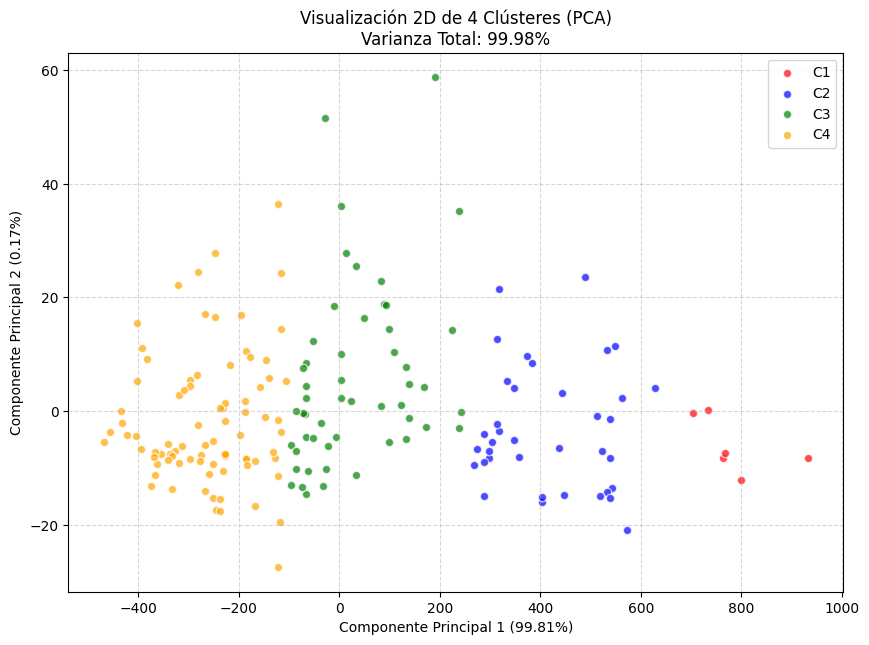

Varianza explicada por los dos ejes: 99.98%


In [93]:
# 1. Configurar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
# Eliminamos la columna 'Cluster' para el cálculo
X_numeric = X.drop(columns=['Cluster'])
componentes = pca.fit_transform(X_numeric)

# 2. Varianza explicada
varianza_pc1 = pca.explained_variance_ratio_[0] * 100
varianza_pc2 = pca.explained_variance_ratio_[1] * 100
varianza_total = varianza_pc1 + varianza_pc2

# 3. Graficar los 4 grupos
plt.figure(figsize=(10, 7))
# Definimos colores fijos para asegurar que C4 sea visible
colores = {'C1': 'red', 'C2': 'blue', 'C3': 'green', 'C4': 'orange'}

for cluster in sorted(X['Cluster'].unique()):
    indices = X['Cluster'] == cluster
    plt.scatter(componentes[indices, 0], componentes[indices, 1],
                c=colores.get(cluster, 'black'), label=cluster, alpha=0.7, edgecolors='w')

plt.title(f'Visualización 2D de 4 Clústeres (PCA)\nVarianza Total: {varianza_total:.2f}%')
plt.xlabel(f'Componente Principal 1 ({varianza_pc1:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({varianza_pc2:.2f}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Varianza explicada por los dos ejes: {varianza_total:.2f}%")

---
## <font color='008dc3'> Métricas  </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
Calcula la métrica de la silueta para los grupos obtenidos. ¿Qué tan buenos te parecen los grupos?
</div>

In [96]:
# Calculamos el coeficiente de silueta global
# X_numeric contiene tus 13 variables y 'clusters' son las etiquetas (C1, C2, C3, C4)
score_global = silhouette_score(X_numeric, clusters)

print(f"--- Validación del Modelo ---")
print(f"Coeficiente de Silueta Global: {score_global:.4f}")

--- Validación del Modelo ---
Coeficiente de Silueta Global: 0.5336
